In [2]:
import sys
import os
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import pytorch_lightning as pl

# Add src to path so we can import modules
sys.path.append(os.path.abspath('..'))

from loading.LightningGraphLoader import load_datasets
from models.MyModel import MyModel
from loading.DatasetInfo import DatasetInfo

/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
os.chdir("../..")
os.getcwd()

'/Users/williserdman/Documents/school/spring2026/db4ai/db4ai'

In [4]:
ds_name = "ENGB"
data = load_datasets([ds_name])[ds_name]

dl = data.data.train_dataloader()
graph_data = dl.dataset[0]
# graph_data should be the Data object provided to LightningNodeData
print(f"Loaded graph with {len(graph_data.x[0])} nodes and {len(graph_data.edge_index[1])} edges.")

Data(x=[7126, 3170], edge_index=[2, 35324], y=[7126], train_mask=[7126], val_mask=[7126], test_mask=[7126])
Loaded graph with 3170 nodes and 35324 edges.


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "
/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)
/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/src/loading

In [5]:
checkpoint_path = "optuna_logs/best_params/version_2/checkpoints/epoch=529-step=530.ckpt" # Cora
# checkpoint_path = "optuna_logs/best_params/version_1/checkpoints/epoch=580-step=581.ckpt" # squirrel

# Load the model
try:
    model = MyModel.load_from_checkpoint(checkpoint_path)
    model.eval()
    print("Model loaded successfully")
except Exception as e:
    print(f"Failed to load model: {e}")
    # Fallback or debugging hints
    print("Ensure that hparams.yaml contains valid ds_info and that the class is importable.")

Model loaded successfully


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/src/models/MyModel.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.cse = nn.CrossEntropyLoss(torch.tensor(ds_info.class_weights))


In [6]:
# Run the model on the full graph
with torch.no_grad():
    # Model expects 'data' object with .x and .edge_index
    logits, _ = model(graph_data)
    probs = torch.softmax(logits, dim=1)
    predictions = logits.argmax(dim=1)

# Calculate accuracy
# Assuming y is the ground truth labels
ground_truth = graph_data.y
# accuracy per node
correct_predictions = (predictions == ground_truth)
accuracy_per_node = correct_predictions.float()

print(f"Overall Accuracy: {accuracy_per_node.mean().item():.4f}")

# You can inspect specific nodes
print(f"First 10 nodes correct? {correct_predictions[:10].tolist()}")

train_mask = graph_data.train_mask
val_mask = graph_data.val_mask
test_mask = graph_data.test_mask


# Calculate accuracy per split
train_accuracy = accuracy_per_node[train_mask].mean().item()
val_accuracy = accuracy_per_node[val_mask].mean().item()
test_accuracy = accuracy_per_node[test_mask].mean().item()

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Val Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Overall Accuracy: 0.7241
First 10 nodes correct? [False, False, True, False, True, False, True, False, True, False]
Train Accuracy: 0.7258
Val Accuracy: 0.7060
Test Accuracy: 0.7370


Computing layout (this may take a moment)...
Drawing graph...


Computing layout (this may take a moment)...
Drawing graph...


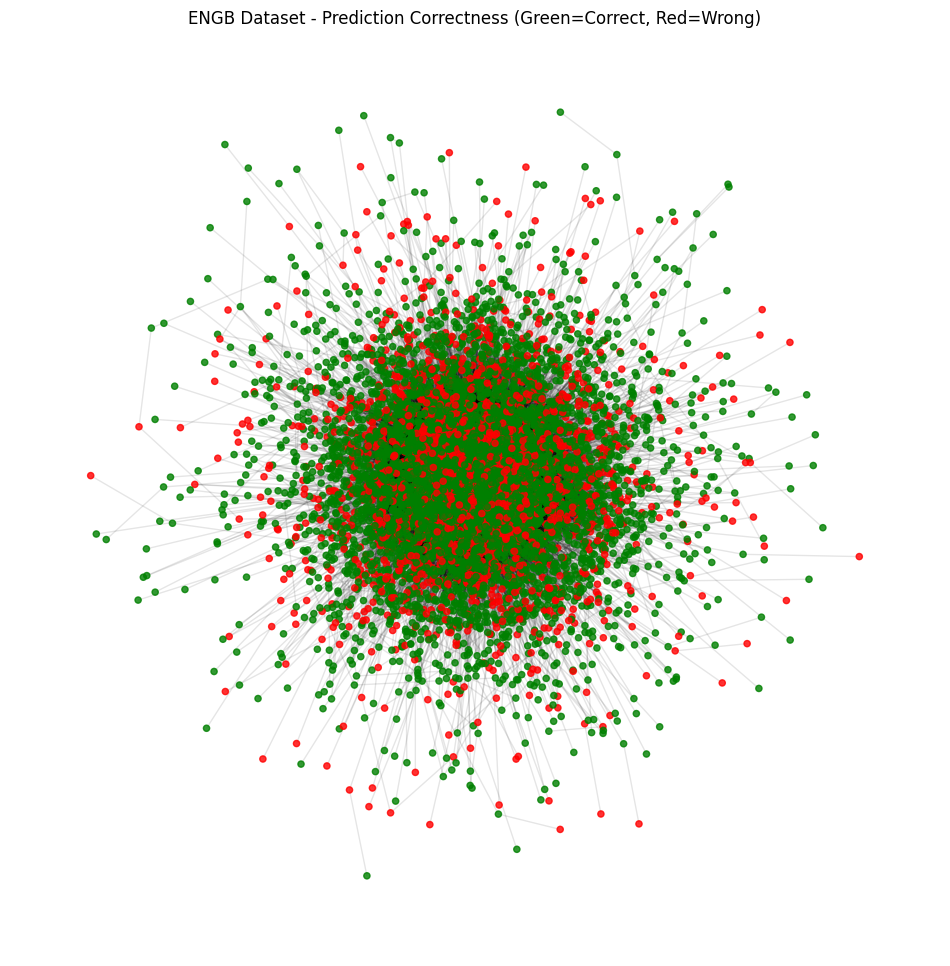

In [7]:
# Visualization
# Convert PyG data to NetworkX graph
G = to_networkx(graph_data, to_undirected=True)

# Define node colors based on correctness
# Green for correct, Red for incorrect
node_colors = ['green' if correct else 'red' for correct in correct_predictions.tolist()]

plt.figure(figsize=(12, 12))
print("Computing layout (this may take a moment)...")
# Use spring layout
pos = nx.spring_layout(G, k=0.1, iterations=50) # Reduced iterations for speed

node_edge_colors = []
for i in range(len(G.nodes)):
    if train_mask[i]:
        node_edge_colors.append('black')
    else:
        node_edge_colors.append('blue')

print("Drawing graph...")
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=node_colors, alpha=0.8,) # edgecolors=node_edge_colors)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title(f"{ds_name} Dataset - Prediction Correctness (Green=Correct, Red=Wrong)")
plt.axis('off')
plt.show()

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_29822/3948254421.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_classes)


/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_29822/3948254421.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_classes)


Drawing graph with class label colors...


/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_29822/3948254421.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_classes)


Drawing graph with class label colors...


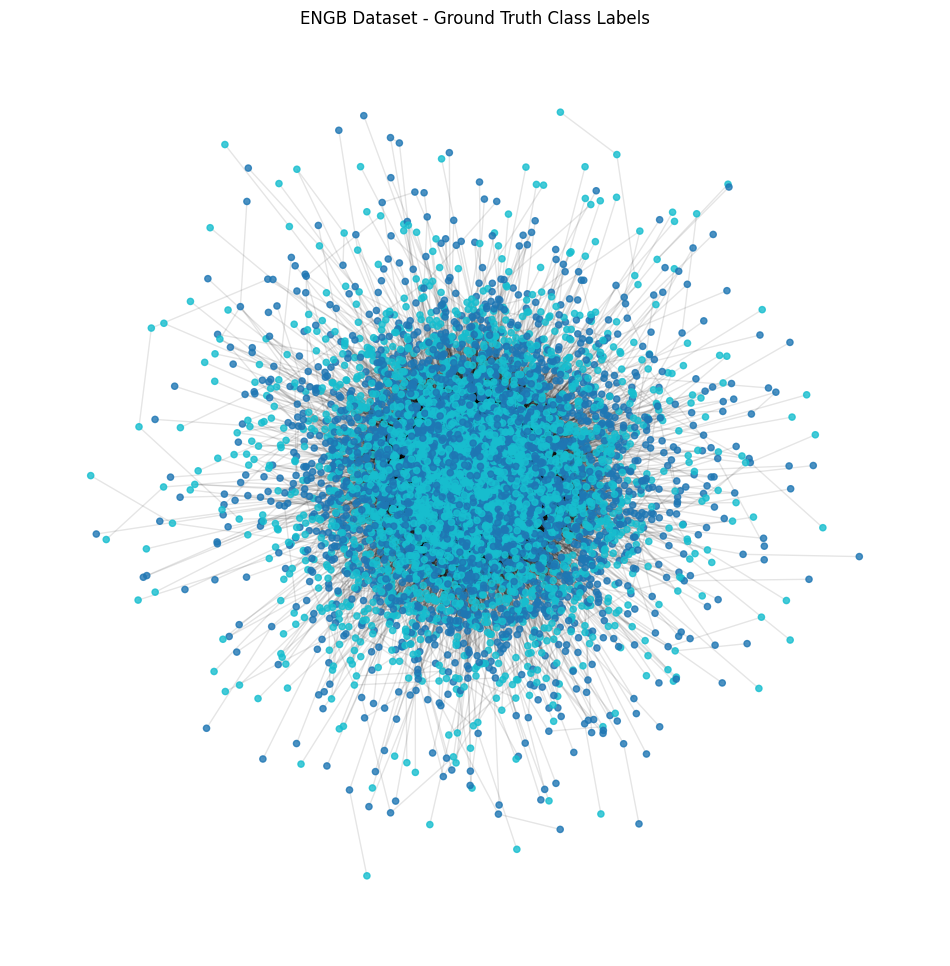

In [8]:
import numpy as np

# Visualize the Cora graph with node colors based on ground truth class labels

# Assign a color to each class label
import matplotlib.cm as cm

num_classes = len(torch.unique(ground_truth))
cmap = cm.get_cmap('tab10', num_classes)
class_colors = [cmap(label.item()) for label in ground_truth]

plt.figure(figsize=(12, 12))
print("Drawing graph with class label colors...")
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=class_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title(f"{ds_name} Dataset - Ground Truth Class Labels")
plt.axis('off')
plt.show()

Original graph: 7126 nodes, 35324 edges
Subgraph (All Correct Nodes): 5160 nodes, 18715 edges


Original graph: 7126 nodes, 35324 edges
Subgraph (All Correct Nodes): 5160 nodes, 18715 edges


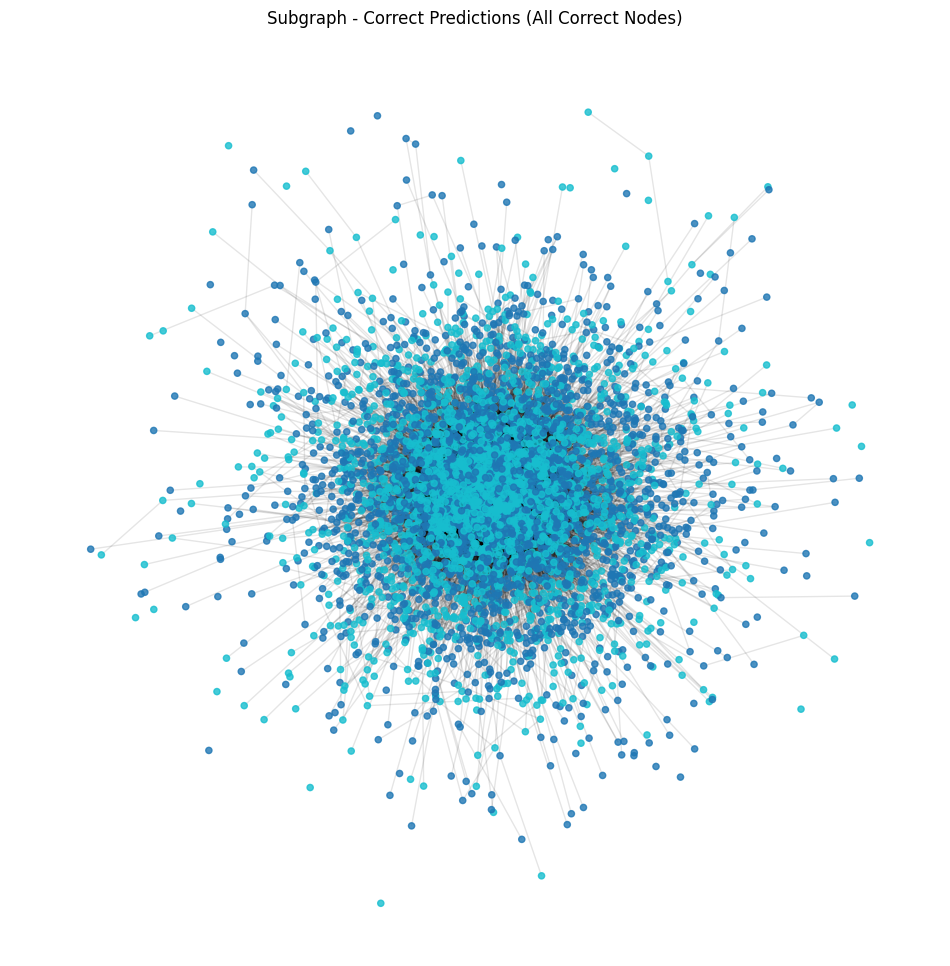

In [9]:
# Flag to filter for training nodes only
TRAINING_NODES = False
TRAIN_AND_VAL = False

# Create a mask for nodes to include
if TRAINING_NODES:
    # Intersection: Correctly predicted AND in training set
    subset_mask = correct_predictions & train_mask
    title_suffix = " (Training Nodes Only)"
elif TRAIN_AND_VAL:
    subset_mask = correct_predictions & (train_mask | val_mask)
    title_suffix = " (Training and Validation Nodes)"
else:
    # Just correctly predicted nodes
    subset_mask = correct_predictions
    title_suffix = " (All Correct Nodes)"

subset_indices = torch.where(subset_mask)[0].tolist()
subgraph = G.subgraph(subset_indices).copy()

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Subgraph{title_suffix}: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

# Visualize the subgraph
plt.figure(figsize=(12, 12))
pos_subgraph = {node: pos[node] for node in subgraph.nodes()}
# Use the same colors as the original graph (by node index)
subgraph_colors = [class_colors[node] for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos_subgraph, node_size=20, node_color=subgraph_colors, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos_subgraph, alpha=0.1)

plt.title(f"Subgraph - Correct Predictions{title_suffix}")
plt.axis('off')
plt.show()

Subgraph (Training and Validation Nodes): 1591 nodes, 1778 edges


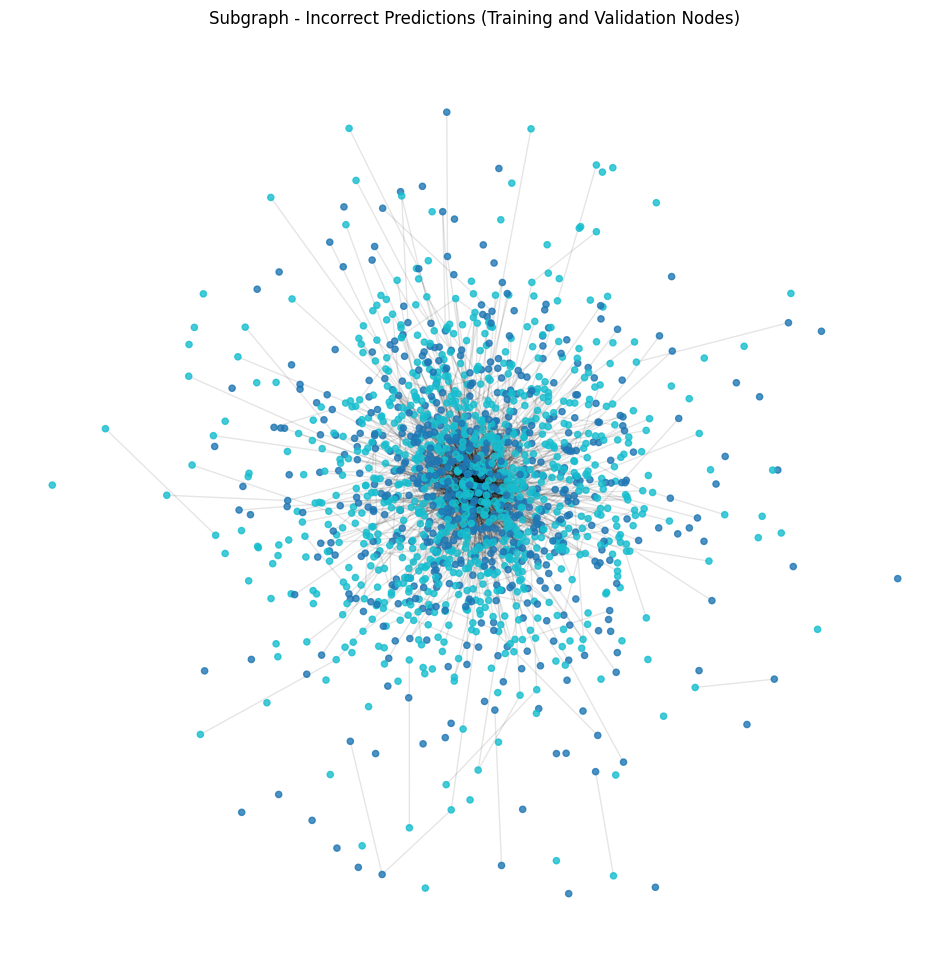

In [10]:
# Flag to filter for training nodes only
TRAINING_NODES = False
TRAIN_AND_VAL = True

# Create a mask for nodes to include
if TRAINING_NODES:
    # Intersection: Correctly predicted AND in training set
    subset_mask = (correct_predictions==0) & train_mask
    title_suffix = " (Training Nodes Only)"
elif TRAIN_AND_VAL:
    subset_mask = (correct_predictions==0) & (train_mask | val_mask)
    title_suffix = " (Training and Validation Nodes)"
else:
    # Just correctly predicted nodes
    subset_mask = correct_predictions
    title_suffix = " (All Correct Nodes)"

subset_indices = torch.where(subset_mask)[0].tolist()
subgraph = G.subgraph(subset_indices).copy()

print(f"Subgraph{title_suffix}: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

# Visualize the subgraph
plt.figure(figsize=(12, 12))
pos_subgraph = {node: pos[node] for node in subgraph.nodes()}
# Use the same colors as the original graph (by node index)
subgraph_colors = [class_colors[node] for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos_subgraph, node_size=20, node_color=subgraph_colors, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos_subgraph, alpha=0.1)

plt.title(f"Subgraph - Incorrect Predictions{title_suffix}")
plt.axis('off')
plt.show()

Edges: Correct-Correct: 18715, Incorrect-Incorrect: 2719, Mixed: 13890


Edges: Correct-Correct: 18715, Incorrect-Incorrect: 2719, Mixed: 13890


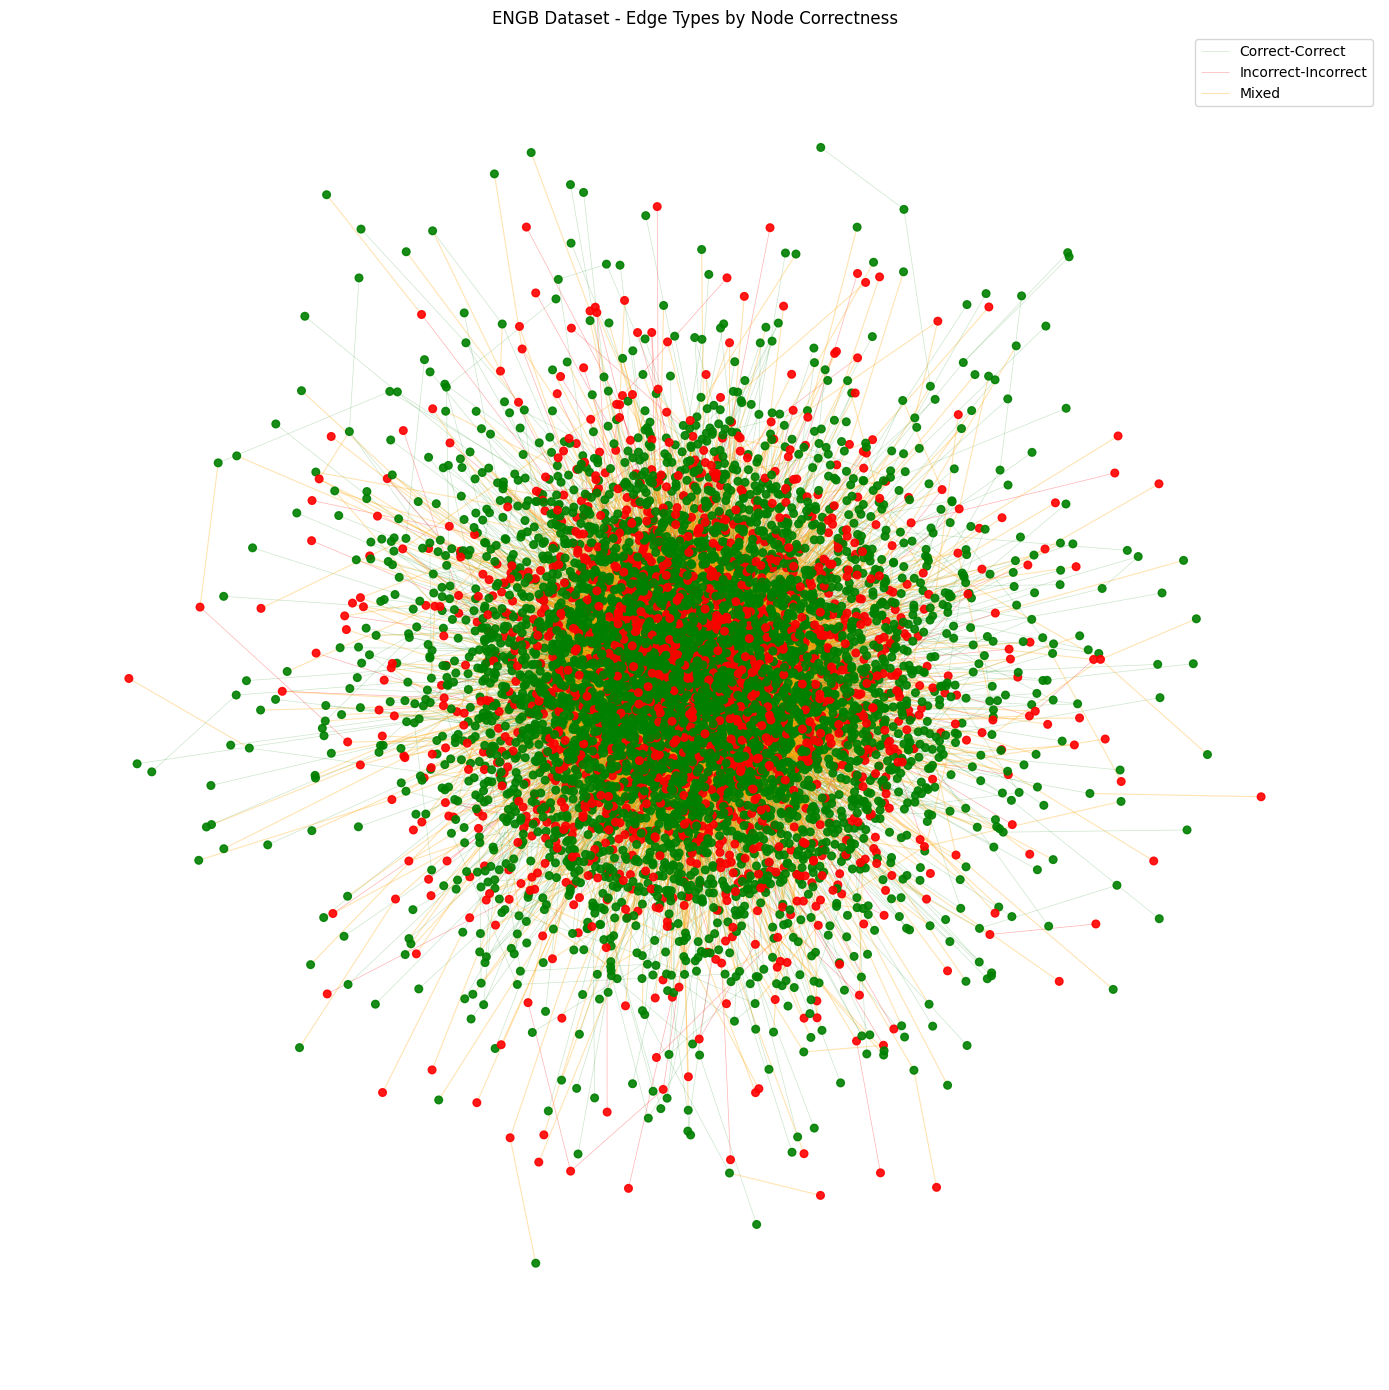


Edge Distribution:
Correct-Correct: 52.98%
Incorrect-Incorrect: 7.70%
Mixed (boundary): 39.32%


In [11]:
# Create a graph with edges colored based on whether they connect correct/incorrect nodes
fig, ax = plt.subplots(figsize=(14, 14))

# Separate edges into three categories
correct_to_correct = []
incorrect_to_incorrect = []
mixed_edges = []

for edge in G.edges():
    node1, node2 = edge
    node1_correct = correct_predictions[node1].item()
    node2_correct = correct_predictions[node2].item()
    
    if node1_correct and node2_correct:
        correct_to_correct.append(edge)
    elif not node1_correct and not node2_correct:
        incorrect_to_incorrect.append(edge)
    else:
        mixed_edges.append(edge)

print(f"Edges: Correct-Correct: {len(correct_to_correct)}, "
      f"Incorrect-Incorrect: {len(incorrect_to_incorrect)}, "
      f"Mixed: {len(mixed_edges)}")

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, alpha=0.9)

# Draw edges with different colors
nx.draw_networkx_edges(G, pos, edgelist=correct_to_correct, 
                       edge_color='green', alpha=0.2, width=0.5, label='Correct-Correct')
nx.draw_networkx_edges(G, pos, edgelist=incorrect_to_incorrect, 
                       edge_color='red', alpha=0.3, width=0.5, label='Incorrect-Incorrect')
nx.draw_networkx_edges(G, pos, edgelist=mixed_edges, 
                       edge_color='orange', alpha=0.3, width=0.8, label='Mixed')

plt.title(f"{ds_name} Dataset - Edge Types by Node Correctness")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
total_edges = G.number_of_edges()
print(f"\nEdge Distribution:")
print(f"Correct-Correct: {len(correct_to_correct)/total_edges:.2%}")
print(f"Incorrect-Incorrect: {len(incorrect_to_incorrect)/total_edges:.2%}")
print(f"Mixed (boundary): {len(mixed_edges)/total_edges:.2%}")

In [12]:
# Print the test mask
print("Test mask:")
print(test_mask.tolist())

# Get indices of nodes in the test set that were correctly predicted
test_correct_indices = torch.where(test_mask & correct_predictions)[0].tolist()
print(f"\nIndices of correctly predicted nodes in test set:")
print(test_correct_indices)
print(f"Number of correct predictions in test set: {len(test_correct_indices)}")

Test mask:
[False, True, True, False, True, False, True, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, True, True, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False

In [13]:
#####################
###   AE CONFIG   ###
#####################

ALL_CORRECT_NODES = True
CORRECT_WITH_VAL = False
ALL_NODES = False

Correctly predicted nodes subgraph: 5160 nodes, 18715 edges
Largest connected component: 4779 nodes, 18688 edges


Correctly predicted nodes subgraph: 5160 nodes, 18715 edges
Largest connected component: 4779 nodes, 18688 edges


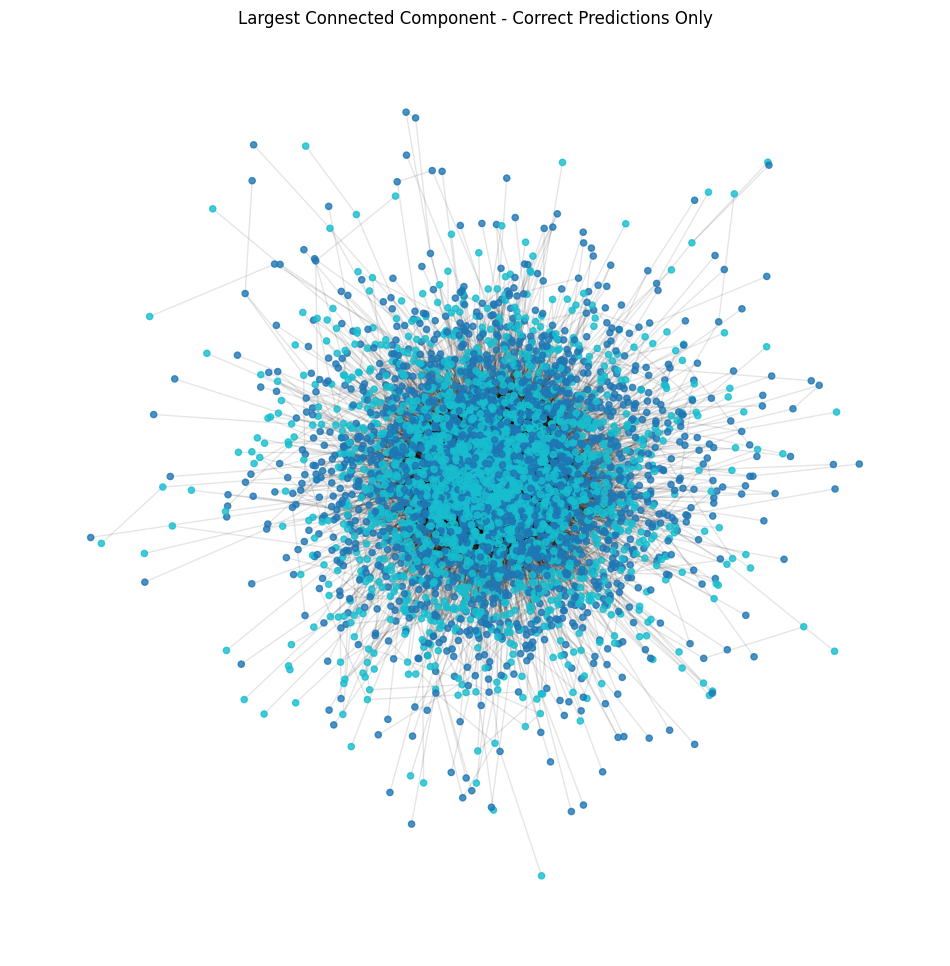

In [14]:
from torch_geometric.utils import to_undirected

# Get subgraph of only correctly predicted nodes
correct_node_indices = torch.where(correct_predictions)[0].tolist()
subgraph_correct = G.subgraph(correct_node_indices).copy()

# Find the largest connected component
largest_cc = max(nx.connected_components(subgraph_correct), key=len)
largest_cc_subgraph = subgraph_correct.subgraph(largest_cc).copy()

print(f"Correctly predicted nodes subgraph: {subgraph_correct.number_of_nodes()} nodes, {subgraph_correct.number_of_edges()} edges")
print(f"Largest connected component: {largest_cc_subgraph.number_of_nodes()} nodes, {largest_cc_subgraph.number_of_edges()} edges")

# Visualize the largest component
plt.figure(figsize=(12, 12))
pos_lcc = {node: pos[node] for node in largest_cc_subgraph.nodes()}
lcc_colors = [class_colors[node] for node in largest_cc_subgraph.nodes()]

nx.draw_networkx_nodes(largest_cc_subgraph, pos_lcc, node_size=20, node_color=lcc_colors, alpha=0.8)
nx.draw_networkx_edges(largest_cc_subgraph, pos_lcc, alpha=0.1)

plt.title(f"Largest Connected Component - Correct Predictions Only")
plt.axis('off')
plt.show()

Correctly predicted nodes subgraph: 5160 nodes, 18715 edges
Largest connected component: 4779 nodes, 18688 edges


Correctly predicted nodes subgraph: 5160 nodes, 18715 edges
Largest connected component: 4779 nodes, 18688 edges


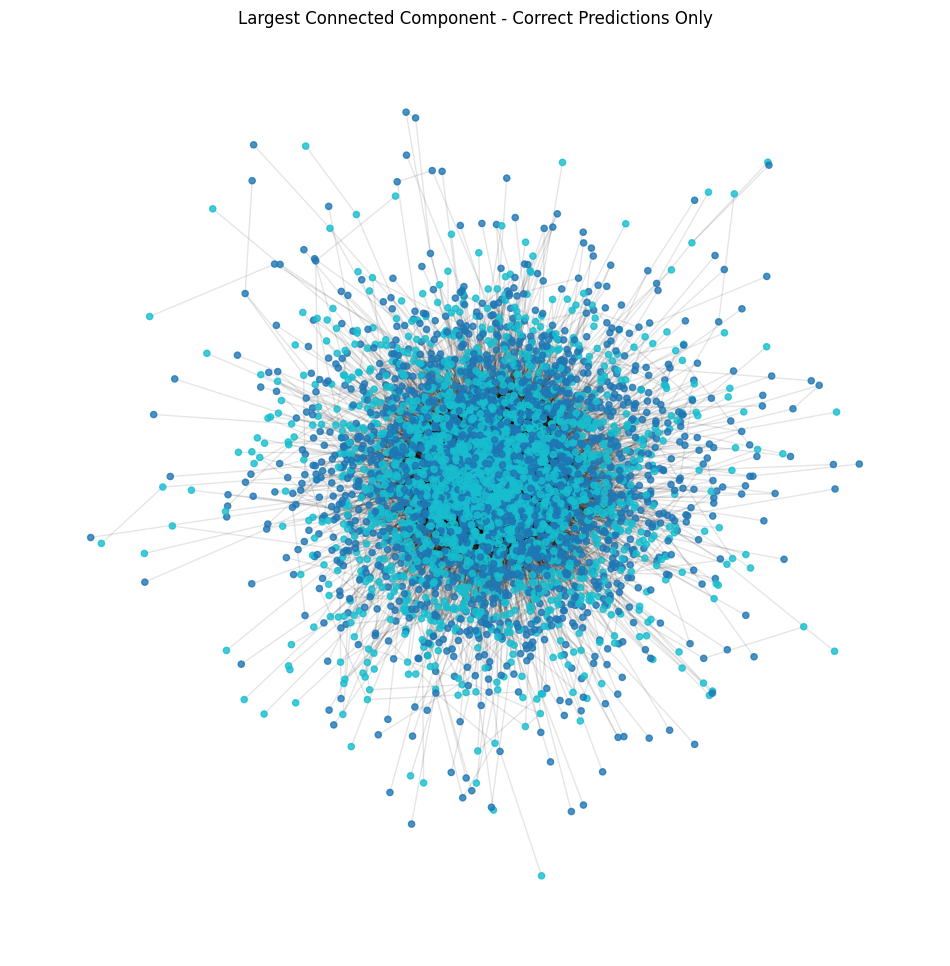

In [15]:
from torch_geometric.utils import to_undirected

# Get subgraph of only correctly predicted nodes
correct_node_indices = torch.where(correct_predictions)[0].tolist()
subgraph_correct = G.subgraph(correct_node_indices).copy()

# Find the largest connected component
largest_cc = max(nx.connected_components(subgraph_correct), key=len)
largest_cc_subgraph = subgraph_correct.subgraph(largest_cc).copy()

print(f"Correctly predicted nodes subgraph: {subgraph_correct.number_of_nodes()} nodes, {subgraph_correct.number_of_edges()} edges")
print(f"Largest connected component: {largest_cc_subgraph.number_of_nodes()} nodes, {largest_cc_subgraph.number_of_edges()} edges")

# Visualize the largest component
plt.figure(figsize=(12, 12))
pos_lcc = {node: pos[node] for node in largest_cc_subgraph.nodes()}
lcc_colors = [class_colors[node] for node in largest_cc_subgraph.nodes()]

nx.draw_networkx_nodes(largest_cc_subgraph, pos_lcc, node_size=20, node_color=lcc_colors, alpha=0.8)
nx.draw_networkx_edges(largest_cc_subgraph, pos_lcc, alpha=0.1)

plt.title(f"Largest Connected Component - Correct Predictions Only")
plt.axis('off')
plt.show()

In [16]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

subset_indices = torch.tensor(list(largest_cc))
x_correct = graph_data.x[subset_indices] # get corresponding features

class StandardAutoencoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(StandardAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels)
        )
        self.decoder = nn.Sequential(
            nn.Linear(out_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, in_channels)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

in_channels = graph_data.num_node_features
hidden_channels = 128
out_channels = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ae = StandardAutoencoder(in_channels, hidden_channels, out_channels).to(device)
optimizer = torch.optim.Adam(model_ae.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)
criterion = nn.MSELoss()

x_correct = x_correct.to(device)

model_ae.train()
for epoch in range(1, 4001):
    optimizer.zero_grad()
    reconstructed = model_ae(x_correct)
    loss = criterion(reconstructed, x_correct)
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss)
    
    if epoch % 50 == 0:
        print(f'Epoch: {epoch:04d}, Loss: {loss.item():.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

print("Standard Autoencoder Training Complete.")


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:1340: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:1340: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch: 0050, Loss: 0.0000, LR: 0.010000
Epoch: 0100, Loss: 0.0000, LR: 0.010000
Epoch: 0150, Loss: 0.0000, LR: 0.010000
Epoch: 0200, Loss: 0.0000, LR: 0.010000
Epoch: 0250, Loss: 0.0000, LR: 0.010000
Epoch: 0300, Loss: 0.0000, LR: 0.010000
Epoch: 0350, Loss: 0.0000, LR: 0.005000
Epoch: 0400, Loss: 0.0000, LR: 0.005000
Epoch: 0450, Loss: 0.0000, LR: 0.005000
Epoch: 0500, Loss: 0.0000, LR: 0.005000
Epoch: 0550, Loss: 0.0000, LR: 0.002500
Epoch: 0600, Loss: 0.0000, LR: 0.002500
Epoch: 0650, Loss: 0.0000, LR: 0.002500
Epoch: 0700, Loss: 0.0000, LR: 0.002500
Epoch: 0750, Loss: 0.0000, LR: 0.001250
Epoch: 0800, Loss: 0.0000, LR: 0.001250
Epoch: 0850, Loss: 0.0000, LR: 0.001250
Epoch: 0900, Loss: 0.0000, LR: 0.001250
Epoch: 0950, Loss: 0.0000, LR: 0.000625
Epoch: 1000, Loss: 0.0000, LR: 0.000625
Epoch: 1050, Loss: 0.0000, LR: 0.000625
Epoch: 1100, Loss: 0.0000, LR: 0.000625
Epoch: 1150, Loss: 0.0000, LR: 0.000313
Epoch: 1200, Loss: 0.0000, LR: 0.000313
Epoch: 1250, Loss: 0.0000, LR: 0.000313


In [17]:
from torch_geometric.utils import k_hop_subgraph
import copy

k_hops = 1

# 1. Get k-hop neighbors of incorrect nodes
incorrect_nodes = torch.where(~correct_predictions)[0]
subset, _, _, _ = k_hop_subgraph(incorrect_nodes, num_hops=k_hops, edge_index=graph_data.edge_index)

print(f"Number of incorrect nodes: {len(incorrect_nodes)}")
print(f"Number of nodes in {k_hops}-hop neighborhood (including incorrect nodes): {len(subset)}")

# 2. Calculate reconstruction error for this group
model_ae.eval()
with torch.no_grad():
    x_k_hop = graph_data.x[subset].to(device)
    x_k_hop_recon = model_ae(x_k_hop)
    
    # Calculate MSE per node
    mse_per_node = torch.nn.functional.mse_loss(x_k_hop_recon, x_k_hop, reduction='none').mean(dim=1)
    mean_error = mse_per_node.mean().item()
    print(f"Mean Reconstruction Error for the {k_hops}-hop neighborhood: {mean_error:.4f}")

# 3. Predict using the reconstructed graph
with torch.no_grad():
    # Pass all features through autoencoder
    x_all = graph_data.x.to(device)
    x_all_recon = model_ae(x_all).cpu()
    
    # Create new graph data with reconstructed features
    graph_data_recon = copy.deepcopy(graph_data)
    graph_data_recon.x = x_all_recon
    
    # Run the GNN model
    model.eval()
    logits_recon, _ = model(graph_data_recon)
    predictions_recon = logits_recon.argmax(dim=1)
    
    correct_predictions_recon = (predictions_recon == graph_data_recon.y)
    accuracy_recon = correct_predictions_recon.float()
    
    print(f"\n--- Prediction Results ---")
    print(f"Original Overall Accuracy: {accuracy_per_node.mean().item():.4f}")
    print(f"Reconstructed Graph Overall Accuracy: {accuracy_recon.mean().item():.4f}")
    
    # Check if previously incorrect nodes improved
    incorrect_mask = ~correct_predictions
    now_correct = correct_predictions_recon[incorrect_mask].sum().item()
    print(f"Number of previously incorrect nodes that are now correct: {now_correct} out of {len(incorrect_nodes)}")

Number of incorrect nodes: 1966
Number of nodes in 1-hop neighborhood (including incorrect nodes): 4277
Mean Reconstruction Error for the 1-hop neighborhood: 0.0000

--- Prediction Results ---
Original Overall Accuracy: 0.7241
Reconstructed Graph Overall Accuracy: 0.4528
Number of previously incorrect nodes that are now correct: 790 out of 1966


In [18]:
# --- 1) Uncertainty + confidence diagnostics ---
eps = 1e-12
entropy = -(probs.clamp_min(eps) * probs.clamp_min(eps).log()).sum(dim=1)  # per-node entropy

incorrect_mask = ~correct_predictions
max_prob, pred_class = probs.max(dim=1)

high_conf_threshold = 0.90
high_conf_incorrect_mask = incorrect_mask & (max_prob >= high_conf_threshold)
high_conf_incorrect_indices = torch.where(high_conf_incorrect_mask)[0]

# Top-K by entropy among incorrect nodes
incorrect_indices = torch.where(incorrect_mask)[0]
incorrect_entropy = entropy[incorrect_indices]
order_entropy_desc = torch.argsort(incorrect_entropy, descending=True)

top10_entropy_incorrect = incorrect_indices[order_entropy_desc[:10]]
top100_entropy_incorrect = incorrect_indices[order_entropy_desc[:100]]

print(f"Incorrect nodes: {incorrect_indices.numel()}")
print(f"High-confidence incorrect (>= {high_conf_threshold:.0%}): {high_conf_incorrect_indices.numel()}")

print("\nTop-10 incorrect by entropy:")
for n in top10_entropy_incorrect.tolist():
    print(
        f"node={n}, entropy={entropy[n].item():.4f}, "
        f"max_prob={max_prob[n].item():.4f}, pred={predictions[n].item()}, true={ground_truth[n].item()}"
    )

# --- 2) Selective repair: reconstruct only k-hop neighborhood of problematic nodes ---
# Focus on high-confidence incorrect nodes (as requested). Fallback to top-100 entropy incorrect if empty.
if high_conf_incorrect_indices.numel() > 0:
    target_nodes = high_conf_incorrect_indices
    target_name = "high-confidence incorrect nodes"
else:
    target_nodes = top100_entropy_incorrect
    target_name = "top-100 entropy incorrect nodes (fallback)"

subset_sel, _, _, _ = k_hop_subgraph(
    target_nodes,
    num_hops=k_hops,
    edge_index=graph_data.edge_index
)

print(f"\nRepair target: {target_name}")
print(f"Target nodes: {target_nodes.numel()}, k-hop neighborhood size: {subset_sel.numel()}")

# Build selectively reconstructed graph (no retraining)
graph_data_selective = copy.deepcopy(graph_data)
graph_data_selective.x = graph_data.x.clone()
graph_data_selective.x[subset_sel] = x_all_recon[subset_sel]  # use pretrained AE reconstruction only on selected region

# Run GNN again
model.eval()
with torch.no_grad():
    logits_sel, _ = model(graph_data_selective)
    probs_sel = torch.softmax(logits_sel, dim=1)
    predictions_sel = logits_sel.argmax(dim=1)
    correct_sel = (predictions_sel == ground_truth)

# --- 3) Compare before vs after ---
overall_before = correct_predictions.float().mean().item()
overall_after = correct_sel.float().mean().item()

target_before = correct_predictions[target_nodes].float().mean().item()
target_after = correct_sel[target_nodes].float().mean().item()

incorrect_before_count = (~correct_predictions).sum().item()
incorrect_after_count = (~correct_sel).sum().item()

fixed_total = ((~correct_predictions) & correct_sel).sum().item()
regressed_total = (correct_predictions & (~correct_sel)).sum().item()

print("\n--- Selective Repair Results ---")
print(f"Overall accuracy: {overall_before:.4f} -> {overall_after:.4f}")
print(f"Target-group accuracy: {target_before:.4f} -> {target_after:.4f}")
print(f"Incorrect nodes count: {incorrect_before_count} -> {incorrect_after_count}")
print(f"Fixed nodes (wrong->correct): {fixed_total}")
print(f"Regressed nodes (correct->wrong): {regressed_total}")

# Optional: inspect high-confidence incorrect nodes that got fixed
fixed_high_conf = torch.where(high_conf_incorrect_mask & correct_sel)[0]
print(f"\nHigh-confidence incorrect nodes fixed: {fixed_high_conf.numel()}")
print(f"Sample fixed node ids: {fixed_high_conf[:20].tolist()}")

Incorrect nodes: 1966
High-confidence incorrect (>= 90%): 227

Top-10 incorrect by entropy:
node=299, entropy=0.6931, max_prob=0.5003, pred=0, true=1
node=210, entropy=0.6931, max_prob=0.5004, pred=1, true=0
node=5831, entropy=0.6931, max_prob=0.5006, pred=0, true=1
node=638, entropy=0.6931, max_prob=0.5007, pred=0, true=1
node=6172, entropy=0.6931, max_prob=0.5008, pred=1, true=0
node=946, entropy=0.6931, max_prob=0.5009, pred=0, true=1
node=1867, entropy=0.6931, max_prob=0.5010, pred=1, true=0
node=2849, entropy=0.6931, max_prob=0.5011, pred=1, true=0
node=1144, entropy=0.6931, max_prob=0.5012, pred=0, true=1
node=5965, entropy=0.6931, max_prob=0.5012, pred=0, true=1

Repair target: high-confidence incorrect nodes
Target nodes: 227, k-hop neighborhood size: 1351

--- Selective Repair Results ---
Overall accuracy: 0.7241 -> 0.6763
Target-group accuracy: 0.0000 -> 0.2291
Incorrect nodes count: 1966 -> 2307
Fixed nodes (wrong->correct): 377
Regressed nodes (correct->wrong): 718

High-co

In [19]:
# Revised selective repair: tune scope + blend strength on validation accuracy
# (previous run regressed overall accuracy and did not fix high-confidence errors)

eps = 1e-12
entropy = -(probs.clamp_min(eps) * probs.clamp_min(eps).log()).sum(dim=1)
max_prob, _ = probs.max(dim=1)
incorrect_mask = ~correct_predictions
incorrect_indices = torch.where(incorrect_mask)[0]

# Target sets
high_conf_incorrect_indices = torch.where(incorrect_mask & (max_prob >= high_conf_threshold))[0]
order_entropy_desc = torch.argsort(entropy[incorrect_indices], descending=True)
top100_entropy_incorrect = incorrect_indices[order_entropy_desc[:100]]

target_sets = {
    "high_conf_incorrect": high_conf_incorrect_indices,
    "top100_entropy_incorrect": top100_entropy_incorrect,
}

def evaluate_candidate(target_nodes, scope, alpha):
    if target_nodes.numel() == 0:
        return None

    if scope == "target_only":
        affected = target_nodes
    elif scope == "khop":
        affected, _, _, _ = k_hop_subgraph(
            target_nodes, num_hops=k_hops, edge_index=graph_data.edge_index
        )
    else:
        raise ValueError(f"Unknown scope: {scope}")

    x_new = graph_data.x.clone()
    x_new[affected] = (1 - alpha) * graph_data.x[affected] + alpha * x_all_recon[affected]

    graph_tmp = copy.deepcopy(graph_data)
    graph_tmp.x = x_new

    with torch.no_grad():
        logits_tmp, _ = model(graph_tmp)
        pred_tmp = logits_tmp.argmax(dim=1)
        corr_tmp = (pred_tmp == ground_truth)

    return {
        "scope": scope,
        "alpha": alpha,
        "affected": affected,
        "pred": pred_tmp,
        "corr": corr_tmp,
        "val_acc": corr_tmp[val_mask].float().mean().item(),
        "overall_acc": corr_tmp.float().mean().item(),
    }

alphas = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
scopes = ["target_only", "khop"]

best = None
for target_name, target_nodes in target_sets.items():
    for scope in scopes:
        for alpha in alphas:
            out = evaluate_candidate(target_nodes, scope, alpha)
            if out is None:
                continue
            out["target_name"] = target_name
            out["target_size"] = int(target_nodes.numel())

            if (best is None) or (out["val_acc"] > best["val_acc"]) or (
                out["val_acc"] == best["val_acc"] and out["overall_acc"] > best["overall_acc"]
            ):
                best = out

if best is None:
    print("No valid candidate found.")
else:
    corr_best = best["corr"]
    pred_best = best["pred"]

    overall_before = correct_predictions.float().mean().item()
    overall_after = corr_best.float().mean().item()

    incorrect_before_count = (~correct_predictions).sum().item()
    incorrect_after_count = (~corr_best).sum().item()

    fixed_total = ((~correct_predictions) & corr_best).sum().item()
    regressed_total = (correct_predictions & (~corr_best)).sum().item()

    # target-specific result for chosen target
    chosen_targets = target_sets[best["target_name"]]
    target_before = correct_predictions[chosen_targets].float().mean().item() if chosen_targets.numel() else float("nan")
    target_after = corr_best[chosen_targets].float().mean().item() if chosen_targets.numel() else float("nan")

    print("Best config (by validation accuracy):")
    print(f"  target set   : {best['target_name']} (n={best['target_size']})")
    print(f"  scope        : {best['scope']}")
    print(f"  alpha        : {best['alpha']}")
    print(f"  affected size: {best['affected'].numel()}")

    print("\n--- Updated Selective Repair Results ---")
    print(f"Validation accuracy: {train_accuracy:.4f} (train baseline), {val_accuracy:.4f} (val baseline), best val={best['val_acc']:.4f}")
    print(f"Overall accuracy: {overall_before:.4f} -> {overall_after:.4f}")
    print(f"Target-group accuracy: {target_before:.4f} -> {target_after:.4f}")
    print(f"Incorrect nodes count: {incorrect_before_count} -> {incorrect_after_count}")
    print(f"Fixed nodes (wrong->correct): {fixed_total}")
    print(f"Regressed nodes (correct->wrong): {regressed_total}")

    # Persist best outputs for downstream cells
    predictions_sel = pred_best
    probs_sel = torch.softmax(logits_tmp, dim=1) if 'logits_tmp' in locals() else probs_sel
    correct_sel = corr_best

Best config (by validation accuracy):
  target set   : top100_entropy_incorrect (n=100)
  scope        : target_only
  alpha        : 0.7
  affected size: 100

--- Updated Selective Repair Results ---
Validation accuracy: 0.7258 (train baseline), 0.7060 (val baseline), best val=0.7151
Overall accuracy: 0.7241 -> 0.7306
Target-group accuracy: 0.0000 -> 0.5000
Incorrect nodes count: 1966 -> 1920
Fixed nodes (wrong->correct): 70
Regressed nodes (correct->wrong): 24


In [20]:
# Counterfactual witness search:
# "Which edge(s), when removed, turn a wrong prediction into a correct one?"

MAX_WRONG_NODES = 100          # keep this small first; increase if needed
TOP_NEIGHBORS_TO_TEST = 20     # AE-guided candidates per wrong node

model.eval()
model_device = next(model.parameters()).device

# AE-based node anomaly score (used to prioritize neighbors)
ae_node_err = torch.nn.functional.mse_loss(
    x_all_recon, graph_data.x, reduction="none"
).mean(dim=1)

wrong_nodes_all = torch.where(~correct_predictions)[0]
# prioritize wrong nodes that also look anomalous under AE
wrong_order = torch.argsort(ae_node_err[wrong_nodes_all], descending=True)
wrong_nodes = wrong_nodes_all[wrong_order[:MAX_WRONG_NODES]]

def remove_edge_both_directions(edge_index, u, v):
    src, dst = edge_index
    keep = ~(((src == u) & (dst == v)) | ((src == v) & (dst == u)))
    return edge_index[:, keep]

witnesses = []
tested = 0

with torch.no_grad():
    for u_t in wrong_nodes:
        u = int(u_t.item())
        true_u = int(ground_truth[u].item())
        pred_u = int(predictions[u].item())

        # Undirected neighborhood from NetworkX graph
        neigh = list(G.neighbors(u))
        if len(neigh) == 0:
            continue

        # AE-guided: test neighbors with highest reconstruction error first
        neigh_t = torch.tensor(neigh, dtype=torch.long)
        neigh_order = torch.argsort(ae_node_err[neigh_t], descending=True)
        candidates = neigh_t[neigh_order[:TOP_NEIGHBORS_TO_TEST]].tolist()

        for v in candidates:
            tested += 1
            new_ei = remove_edge_both_directions(graph_data.edge_index, u, v)

            cf_data = copy.deepcopy(graph_data)
            cf_data.edge_index = new_ei.to(model_device)
            cf_data.x = graph_data.x.to(model_device)

            logits_cf, _ = model(cf_data)
            logits_cf = logits_cf.cpu()

            pred_cf_u = int(logits_cf[u].argmax().item())
            fixed = (pred_cf_u == true_u)

            if fixed:
                p_true_before = probs[u, true_u].item()
                p_true_after = torch.softmax(logits_cf[u], dim=0)[true_u].item()

                witnesses.append({
                    "wrong_node": u,
                    "neighbor": int(v),
                    "baseline_pred": pred_u,
                    "true_label": true_u,
                    "ae_err_node": float(ae_node_err[u].item()),
                    "ae_err_neighbor": float(ae_node_err[v].item()),
                    "p_true_before": p_true_before,
                    "p_true_after": p_true_after,
                    "p_true_gain": p_true_after - p_true_before,
                })

# Sort strongest witnesses by probability gain for true class
witnesses = sorted(witnesses, key=lambda d: d["p_true_gain"], reverse=True)

print(f"Tested wrong nodes: {len(wrong_nodes)}")
print(f"Edges tested: {tested}")
print(f"Counterfactual witnesses found: {len(witnesses)}")

print("\nTop 20 witnesses:")
for w in witnesses[:20]:
    print(
        f"u={w['wrong_node']}, v={w['neighbor']}, "
        f"pred={w['baseline_pred']} -> true={w['true_label']}, "
        f"p_true: {w['p_true_before']:.4f}->{w['p_true_after']:.4f} "
        f"(+{w['p_true_gain']:.4f}), "
        f"AE(nei)={w['ae_err_neighbor']:.2e}"
    )

# Optional: unique witness edge set for downstream usage
witness_edges = {(w["wrong_node"], w["neighbor"]) for w in witnesses}
print(f"\nUnique witness edges: {len(witness_edges)}")

Tested wrong nodes: 100
Edges tested: 851
Counterfactual witnesses found: 40

Top 20 witnesses:
u=6996, v=1492, pred=1 -> true=0, p_true: 0.0000->0.9552 (+0.9551), AE(nei)=9.26e-06
u=2090, v=2158, pred=1 -> true=0, p_true: 0.0036->0.9032 (+0.8996), AE(nei)=1.13e-05
u=4725, v=365, pred=1 -> true=0, p_true: 0.0954->0.9084 (+0.8130), AE(nei)=1.84e-05
u=1741, v=1560, pred=1 -> true=0, p_true: 0.1180->0.9009 (+0.7829), AE(nei)=9.96e-06
u=3790, v=2000, pred=1 -> true=0, p_true: 0.0027->0.7824 (+0.7797), AE(nei)=1.07e-05
u=1809, v=502, pred=1 -> true=0, p_true: 0.1144->0.8503 (+0.7358), AE(nei)=7.58e-06
u=673, v=1013, pred=1 -> true=0, p_true: 0.0129->0.7310 (+0.7181), AE(nei)=1.18e-05
u=5064, v=6247, pred=1 -> true=0, p_true: 0.1905->0.8681 (+0.6776), AE(nei)=2.17e-05
u=4791, v=1137, pred=1 -> true=0, p_true: 0.0731->0.7474 (+0.6743), AE(nei)=1.28e-05
u=4587, v=2832, pred=1 -> true=0, p_true: 0.0381->0.6891 (+0.6510), AE(nei)=1.13e-05
u=6592, v=1174, pred=1 -> true=0, p_true: 0.3827->0.9277 

In [21]:
# AE reconstruction error -> trust score (low error = high trust)
recon_mse = torch.nn.functional.mse_loss(
    x_all_recon, graph_data.x, reduction="none"
).mean(dim=1)

# Normalize to [0,1], where 1 = most trusted
mse_min, mse_max = recon_mse.min(), recon_mse.max()
trust_score = 1.0 - (recon_mse - mse_min) / (mse_max - mse_min + 1e-12)

# OOD flag from high reconstruction error
ood_percentile = 0.95
ood_threshold = torch.quantile(recon_mse, ood_percentile)
ood_mask = recon_mse >= ood_threshold

# Robust counterfactual witness mask:
# a node is "rescued" if it has a strong witness edge flip in `witnesses`
robust_witness_mask = torch.zeros_like(ood_mask, dtype=torch.bool)
MIN_GAIN = 0.10
MIN_P_TRUE_AFTER = 0.50

if "witnesses" in locals() and len(witnesses) > 0:
    for w in witnesses:
        if (w["p_true_gain"] >= MIN_GAIN) and (w["p_true_after"] >= MIN_P_TRUE_AFTER):
            robust_witness_mask[w["wrong_node"]] = True

# Trust rule:
# Untrusted if OOD, unless robust counterfactual witness exists
trusted_mask = (~ood_mask) | robust_witness_mask

# Optional "abstain" prediction: -1 means "do not trust"
trusted_predictions = predictions.clone()
trusted_predictions[~trusted_mask] = -1

# Diagnostics
coverage = trusted_mask.float().mean().item()
trusted_acc = correct_predictions[trusted_mask].float().mean().item() if trusted_mask.any() else float("nan")
untrusted_acc = correct_predictions[~trusted_mask].float().mean().item() if (~trusted_mask).any() else float("nan")

print(f"OOD threshold (p{int(ood_percentile*100)}): {ood_threshold.item():.6e}")
print(f"OOD nodes: {ood_mask.sum().item()} / {ood_mask.numel()} ({ood_mask.float().mean().item():.2%})")
print(f"Robust witness rescued nodes: {robust_witness_mask.sum().item()}")
print(f"Trusted coverage: {coverage:.2%}")
print(f"Accuracy on trusted nodes: {trusted_acc:.4f}")
print(f"Accuracy on untrusted nodes: {untrusted_acc:.4f}")

OOD threshold (p95): 2.131033e-05
OOD nodes: 357 / 7126 (5.01%)
Robust witness rescued nodes: 26
Trusted coverage: 95.34%
Accuracy on trusted nodes: 0.7215
Accuracy on untrusted nodes: 0.7771


In [22]:
# RCW + Trusted-node fusion
# Idea:
# 1) Keep OOD-based trust as default.
# 2) "Rescue" OOD/wrong nodes if they have strong RCW evidence.
# 3) Mark high-frequency RCW-neighbor nodes as risky (optional conservative filter).

# --- Build RCW statistics per node ---
num_nodes = correct_predictions.numel()
rcw_witness_count = torch.zeros(num_nodes, dtype=torch.long)
rcw_max_gain = torch.zeros(num_nodes, dtype=torch.float32)
rcw_neighbor_count = torch.zeros(num_nodes, dtype=torch.long)  # nodes often acting as harmful neighbors

RCW_MIN_GAIN = 0.10
RCW_MIN_P_TRUE_AFTER = 0.50
RISK_NEIGHBOR_COUNT_THRESHOLD = 2  # conservative

if "witnesses" in locals() and len(witnesses) > 0:
    for w in witnesses:
        u = w["wrong_node"]
        v = w["neighbor"]
        gain = float(w["p_true_gain"])
        p_after = float(w["p_true_after"])

        if gain >= RCW_MIN_GAIN and p_after >= RCW_MIN_P_TRUE_AFTER:
            rcw_witness_count[u] += 1
            rcw_max_gain[u] = max(rcw_max_gain[u], gain)
            rcw_neighbor_count[v] += 1

# RCW rescue: wrong nodes with at least one strong witness
rcw_rescue_mask = (rcw_witness_count > 0) & (~correct_predictions)

# RCW risk: nodes repeatedly appearing as harmful neighbors
rcw_risk_mask = rcw_neighbor_count >= RISK_NEIGHBOR_COUNT_THRESHOLD

# --- Fused trust rule ---
# Base trust from OOD
base_trusted_mask = ~ood_mask

# Fused:
# trusted if base trusted, OR RCW-rescued; but apply conservative risk filter for OOD nodes
trusted_mask_rcw = (base_trusted_mask | rcw_rescue_mask) & ~(ood_mask & rcw_risk_mask)

# Abstaining predictions (-1 for untrusted)
trusted_predictions_rcw = predictions.clone()
trusted_predictions_rcw[~trusted_mask_rcw] = -1

# --- Diagnostics ---
coverage_base = trusted_mask.float().mean().item() if "trusted_mask" in locals() else float("nan")
acc_base = correct_predictions[trusted_mask].float().mean().item() if ("trusted_mask" in locals() and trusted_mask.any()) else float("nan")

coverage_rcw = trusted_mask_rcw.float().mean().item()
acc_rcw = correct_predictions[trusted_mask_rcw].float().mean().item() if trusted_mask_rcw.any() else float("nan")
untrusted_acc_rcw = correct_predictions[~trusted_mask_rcw].float().mean().item() if (~trusted_mask_rcw).any() else float("nan")

print("--- RCW + Trusted-node fusion ---")
print(f"OOD percentile: {ood_percentile:.2f}, threshold: {ood_threshold.item():.6e}")
print(f"RCW rescued nodes: {rcw_rescue_mask.sum().item()}")
print(f"RCW risky-neighbor nodes: {rcw_risk_mask.sum().item()}")

print(f"\nBase trusted coverage: {coverage_base:.2%}, base trusted acc: {acc_base:.4f}")
print(f"Fused trusted coverage: {coverage_rcw:.2%}, fused trusted acc: {acc_rcw:.4f}")
print(f"Fused untrusted acc: {untrusted_acc_rcw:.4f}")

# Optional: keep these for later cells
rcw_stats = {
    "rcw_witness_count": rcw_witness_count,
    "rcw_max_gain": rcw_max_gain,
    "rcw_neighbor_count": rcw_neighbor_count,
    "rcw_rescue_mask": rcw_rescue_mask,
    "rcw_risk_mask": rcw_risk_mask,
}

--- RCW + Trusted-node fusion ---
OOD percentile: 0.95, threshold: 2.131033e-05
RCW rescued nodes: 26
RCW risky-neighbor nodes: 0

Base trusted coverage: 95.34%, base trusted acc: 0.7215
Fused trusted coverage: 95.34%, fused trusted acc: 0.7215
Fused untrusted acc: 0.7771


In [23]:
# Quick sanity check: compare all candidate prediction sets against baseline
def eval_preds(pred, name):
    corr = (pred == ground_truth)
    return {
        "name": name,
        "overall": corr.float().mean().item(),
        "train": corr[train_mask].float().mean().item(),
        "val": corr[val_mask].float().mean().item(),
        "test": corr[test_mask].float().mean().item(),
        "corr": corr,
    }

candidates = [eval_preds(predictions, "baseline")]

if "predictions_sel" in locals():
    candidates.append(eval_preds(predictions_sel, "selective_repair"))

if "predictions_recon" in locals():
    candidates.append(eval_preds(predictions_recon, "full_recon"))

if "trusted_predictions" in locals():
    tp = trusted_predictions.clone()
    # abstentions are encoded as -1; treat as incorrect for strict accuracy
    abst_mask = tp == -1
    tp[abst_mask] = predictions[abst_mask]
    candidates.append(eval_preds(tp, "trusted_fallback"))

print("=== Accuracy comparison ===")
for c in candidates:
    print(
        f"{c['name']:>16} | overall={c['overall']:.4f} "
        f"train={c['train']:.4f} val={c['val']:.4f} test={c['test']:.4f}"
    )

base_corr = candidates[0]["corr"]
print("\n=== Delta vs baseline ===")
for c in candidates[1:]:
    fixed = ((~base_corr) & c["corr"]).sum().item()
    regressed = (base_corr & (~c["corr"])).sum().item()
    net = fixed - regressed
    print(f"{c['name']:>16} | fixed={fixed} regressed={regressed} net={net:+d}")

# Keep only if validation improves; otherwise revert to baseline
best = max(candidates, key=lambda x: x["val"])
final_predictions = predictions if best["val"] <= candidates[0]["val"] else (
    predictions_sel if best["name"] == "selective_repair" else predictions_recon
)

print(f"\nSelected final_predictions: {'baseline' if best['val'] <= candidates[0]['val'] else best['name']}")

=== Accuracy comparison ===
        baseline | overall=0.7241 train=0.7258 val=0.7060 test=0.7370
selective_repair | overall=0.7306 train=0.7322 val=0.7151 test=0.7412
      full_recon | overall=0.4528 train=0.4524 val=0.4533 test=0.4537
trusted_fallback | overall=0.7241 train=0.7258 val=0.7060 test=0.7370

=== Delta vs baseline ===
selective_repair | fixed=70 regressed=24 net=+46
      full_recon | fixed=790 regressed=2723 net=-1933
trusted_fallback | fixed=0 regressed=0 net=+0

Selected final_predictions: selective_repair


Incorrect nodes total: 1966
Confident repair pool (0-25% entropy): 491
Ignored very uncertain nodes: 1475


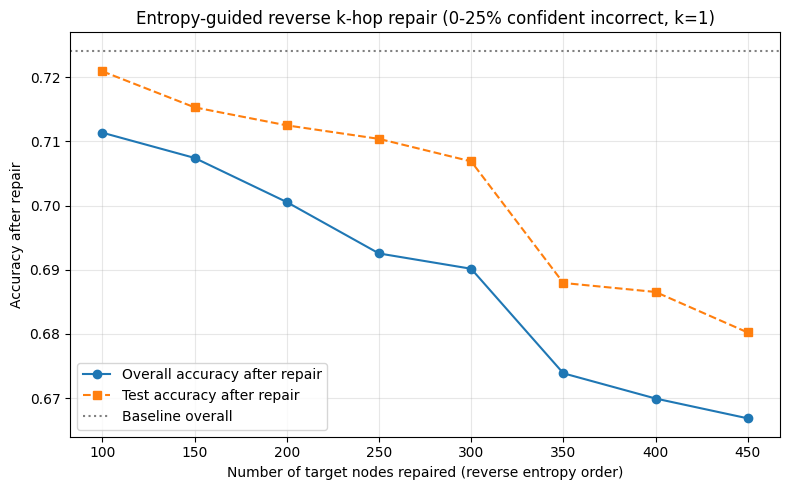

targets= 100 | affected(k-hop union)=  392 | overall_acc=0.7113 | test_acc=0.7209
targets= 150 | affected(k-hop union)=  626 | overall_acc=0.7074 | test_acc=0.7153
targets= 200 | affected(k-hop union)=  899 | overall_acc=0.7005 | test_acc=0.7125
targets= 250 | affected(k-hop union)= 1056 | overall_acc=0.6925 | test_acc=0.7104
targets= 300 | affected(k-hop union)= 1176 | overall_acc=0.6901 | test_acc=0.7069
targets= 350 | affected(k-hop union)= 1692 | overall_acc=0.6739 | test_acc=0.6879
targets= 400 | affected(k-hop union)= 1847 | overall_acc=0.6699 | test_acc=0.6865
targets= 450 | affected(k-hop union)= 1947 | overall_acc=0.6669 | test_acc=0.6802


In [28]:
# Entropy-guided reverse-order k-hop repair curve (AE reconstruction as repair signal)

# --- checks ---
needed = ["probs", "correct_predictions", "graph_data", "model", "x_all_recon", "ground_truth", "k_hops"]
missing = [v for v in needed if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# --- 1) Uncertainty (entropy): ignore very uncertain, keep confident incorrect ---
eps = 1e-12
entropy = -(probs.clamp_min(eps) * probs.clamp_min(eps).log()).sum(dim=1)

incorrect_nodes = torch.where(~correct_predictions)[0]
if incorrect_nodes.numel() == 0:
    raise RuntimeError("No incorrect nodes found.")

# low entropy = confident prediction; keep only 0-25% entropy band among incorrect nodes
order_low_to_high_entropy = torch.argsort(entropy[incorrect_nodes], descending=False)
incorrect_sorted = incorrect_nodes[order_low_to_high_entropy]

q25 = max(1, int(0.25 * incorrect_sorted.numel()))
confident_pool = incorrect_sorted[:q25]  # 0-25% by entropy (most confident incorrect)
ignored_uncertain = incorrect_sorted[q25:]

# reverse order repair as requested
repair_order = torch.flip(confident_pool, dims=[0])

print(f"Incorrect nodes total: {incorrect_nodes.numel()}")
print(f"Confident repair pool (0-25% entropy): {repair_order.numel()}")
print(f"Ignored very uncertain nodes: {ignored_uncertain.numel()}")

# --- 2) Evaluate curve for repaired-node counts 100..500 ---
step = 50
n_values = [n for n in range(100, 501, step) if n <= repair_order.numel()]
if len(n_values) == 0:
    n_values = [int(repair_order.numel())]

model.eval()
model_device = next(model.parameters()).device

curve_overall_acc = []
curve_test_acc = []
curve_affected_nodes = []

with torch.no_grad():
    for n in n_values:
        targets = repair_order[:n]

        # repair full union of k-hop neighborhoods (overlap naturally handled by unique())
        affected_chunks = []
        for t in targets:
            sub, _, _, _ = k_hop_subgraph(
                node_idx=t.view(1),
                num_hops=k_hops,
                edge_index=graph_data.edge_index
            )
            affected_chunks.append(sub)

        affected = torch.unique(torch.cat(affected_chunks, dim=0))
        curve_affected_nodes.append(int(affected.numel()))

        # AE reconstruction-based repair
        x_new = graph_data.x.clone()
        x_new[affected] = x_all_recon[affected]

        g_tmp = copy.deepcopy(graph_data)
        g_tmp.x = x_new.to(model_device)
        g_tmp.edge_index = graph_data.edge_index.to(model_device)

        logits_tmp, _ = model(g_tmp)
        pred_tmp = logits_tmp.argmax(dim=1).cpu()
        corr_tmp = (pred_tmp == ground_truth.cpu())

        curve_overall_acc.append(corr_tmp.float().mean().item())
        curve_test_acc.append(corr_tmp[test_mask].float().mean().item())

# --- 3) Plot ---
plt.figure(figsize=(8, 5))
plt.plot(n_values, curve_overall_acc, marker="o", label="Overall accuracy after repair")
plt.plot(n_values, curve_test_acc, marker="s", linestyle="--", label="Test accuracy after repair")
plt.axhline(y=accuracy_per_node.mean().item(), color="gray", linestyle=":", label="Baseline overall")
plt.xlabel("Number of target nodes repaired (reverse entropy order)")
plt.ylabel("Accuracy after repair")
plt.title(f"Entropy-guided reverse k-hop repair (0-25% confident incorrect, k={k_hops})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional table-like print
for n, a, t, m in zip(n_values, curve_overall_acc, curve_test_acc, curve_affected_nodes):
    print(f"targets={n:4d} | affected(k-hop union)={m:5d} | overall_acc={a:.4f} | test_acc={t:.4f}")